# Efficient Frontier (HK + US mix)

Downloads historical prices for your tickers, computes returns, adds a synthetic 3% money-market series, and runs long-only mean–variance optimization to plot an efficient frontier.

HK tickers on Yahoo usually need `.HK` (e.g. `3466.HK`). If a ticker fails (common for ambiguous symbols like `NASA`), fix it in the mapping cell.

Currency note: returns are unitless, but mixing HKD and USD ignores FX effects unless you explicitly model FX.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import yfinance as yf
except Exception as e:
    raise ImportError('Missing dependency: yfinance. Install with: pip install yfinance') from e

try:
    import cvxpy as cp
except Exception as e:
    raise ImportError('Missing dependency: cvxpy. Install with: pip install cvxpy') from e

In [10]:
# Your requested mix
RAW_TICKERS = ['SPMO', 'VTI', 'VXUS', "DTCR", 'GRID', 'NASA', '3466']

# Map your input symbols to Yahoo Finance symbols.
# Confirmed:
# - NASA: Tema Space Innovators ETF (NASA)
# - 3466: Hang Seng High Dividend 30 Index ETF (3466.HK on Yahoo)
TICKER_MAP = {
    'SPMO': 'SPMO',
    'VTI': 'VTI',
    'VXUS': 'VXUS',
    'DTCR': 'DTCR',
    'GRID': 'GRID',
    'NASA': 'NASA',
    '3466': '3466.HK',
}

TICKERS = [TICKER_MAP[t] for t in RAW_TICKERS]

START_DATE = '2005-01-01'
END_DATE = None
PRICE_FIELD = 'Adj Close'
TRADING_DAYS = 252
MMF_ANNUAL_RETURN = 0.03
RISK_FREE_RATE_ANNUAL = 0.03
MMF_LABEL = 'MMF_3pct'

TICKERS

['SPMO', 'VTI', 'VXUS', 'DTCR', 'GRID', 'NASA', '3466.HK']

In [11]:
def fetch_prices(tickers, start, end, price_field='Adj Close'):
    df = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        auto_adjust=False,
        actions=False,
        progress=False,
        group_by='ticker',
        threads=True,
    )

    if isinstance(df.columns, pd.MultiIndex):
        if price_field in df.columns.get_level_values(0):
            prices = df[price_field].copy()
        elif price_field in df.columns.get_level_values(1):
            prices = df.xs(price_field, axis=1, level=1).copy()
        else:
            raise KeyError(f'Price field {price_field!r} not found in downloaded data')
    else:
        if price_field not in df.columns:
            raise KeyError(f'Price field {price_field!r} not found in downloaded data')
        prices = df[[price_field]].copy()
        prices.columns = [tickers[0]]

    prices.index = pd.to_datetime(prices.index)
    prices = prices.sort_index()
    return prices

prices = fetch_prices(TICKERS, START_DATE, END_DATE, PRICE_FIELD)
missing = [c for c in prices.columns if prices[c].dropna().empty]
if missing:
    print('These tickers returned no price data:', missing)
    print('Fix them by editing TICKER_MAP in the config cell.')

# Add a synthetic money-market price series with a fixed 3% annual return
mmf_daily = (1 + MMF_ANNUAL_RETURN) ** (1 / TRADING_DAYS) - 1
mmf_start = 100.0
mmf_prices = mmf_start * (1 + mmf_daily) ** np.arange(len(prices))
prices[MMF_LABEL] = mmf_prices
prices = prices.sort_index()

display((prices.notna().sum()).to_frame('non_null_rows'))
prices.tail()

,non_null_rows
Ticker,
NASA,19
3466.HK,258
DTCR,1378
SPMO,2650
VXUS,3833
GRID,4134
VTI,5362
MMF_3pct,5369


Ticker,NASA,3466.HK,DTCR,SPMO,VXUS,GRID,VTI,MMF_3pct
Date,,,,,,,,
2026-04-21,31.09,21.680000,27.700001,126.650002,81.879997,180.699997,347.839996,187.607198
2026-04-22,31.59,21.480000,28.100000,129.110001,82.589996,183.990005,351.220001,187.629205
2026-04-23,30.41,21.639999,28.440001,129.229996,81.720001,184.869995,349.799988,187.651215
2026-04-24,29.49,21.639999,28.850000,131.520004,82.489998,187.199997,352.049988,187.673227
2026-04-27,28.33,21.559999,28.469900,131.559998,82.404999,187.184998,351.980011,187.695242


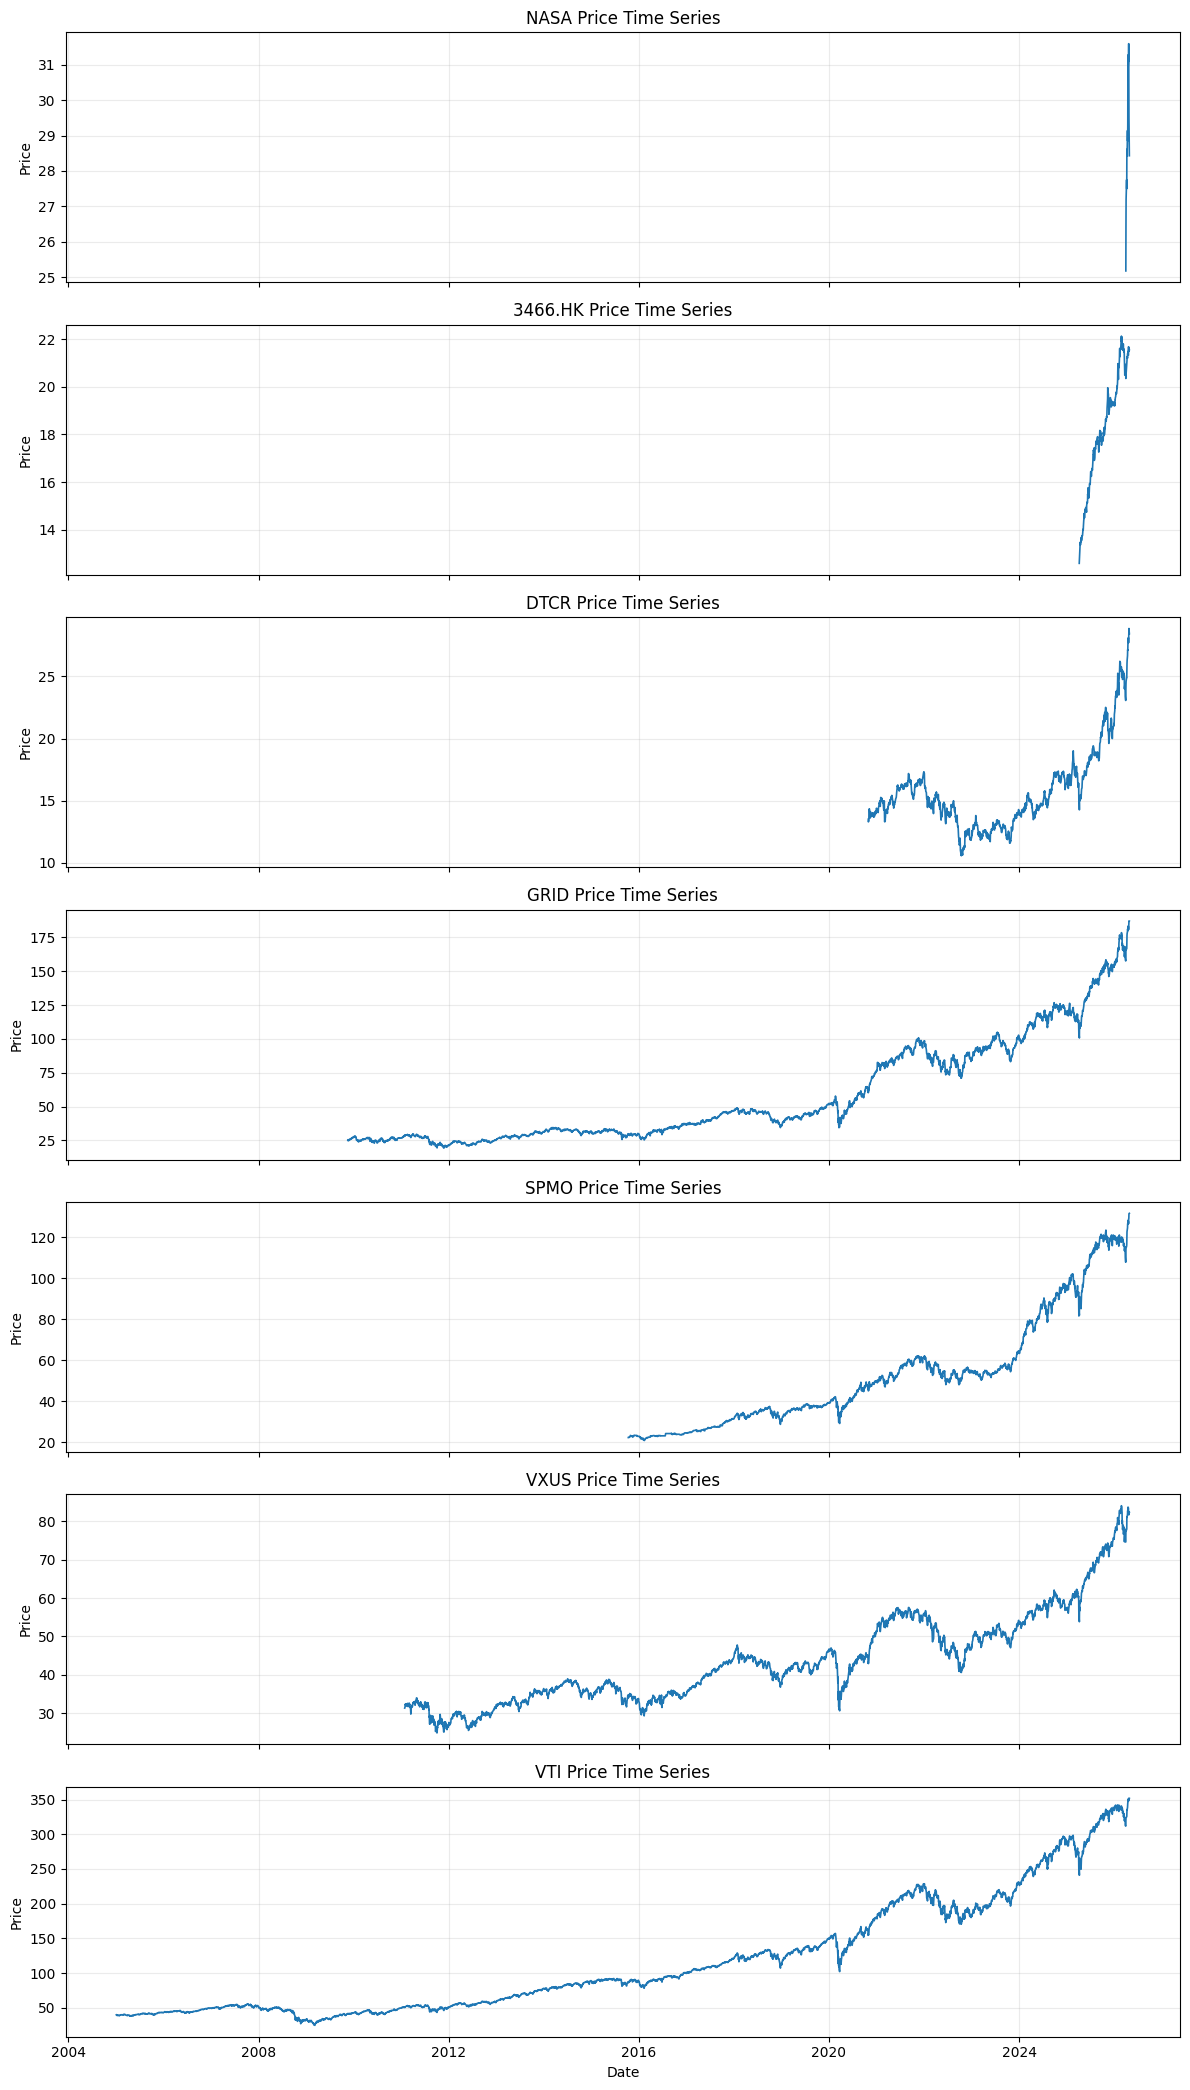

In [8]:
# Time-series plots for each fetched price series
# Uses the `prices` DataFrame created in the fetch cell.

if 'prices' not in globals() or prices.empty:
    raise ValueError("`prices` is not available. Run the fetch-prices cell first.")

n_assets = len(prices.columns)
fig, axes = plt.subplots(n_assets, 1, figsize=(12, max(3 * n_assets, 6)), sharex=True)

if n_assets == 1:
    axes = [axes]

for ax, ticker in zip(axes, prices.columns):
    series = prices[ticker].dropna()
    ax.plot(series.index, series.values, linewidth=1.2)
    ax.set_title(f"{ticker} Price Time Series")
    ax.set_ylabel("Price")
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

In [16]:
# Daily returns from fetched prices (do not drop tickers by coverage)
returns = prices.pct_change().dropna(how='all')

# Coverage stats
min_coverage = 0.67
coverage = prices.notna().mean()

# Expected value (mean) and standard deviation of DAILY returns
compounded_daily_return = (1 + returns).prod() ** (1 / returns.count()) - 1
daily_stats = pd.DataFrame({
    'coverage_ratio': coverage,
    'expected_daily_return': compounded_daily_return,
    'std_daily_return': returns.std(skipna=True),
    'valid_return_obs': returns.count(),
}).sort_values('coverage_ratio', ascending=False)

# Keep all tickers; just report them separately by coverage group
sufficient_stats = daily_stats[daily_stats['coverage_ratio'] >= min_coverage]
insufficient_stats = daily_stats[daily_stats['coverage_ratio'] < min_coverage]

print('Tickers with sufficient coverage (>= 67%)')
display(sufficient_stats)

print('Tickers with insufficient coverage (< 67%)')
display(insufficient_stats)

# Add synthetic money-market returns for downstream optimization cells
mmf_daily = (1 + MMF_ANNUAL_RETURN) ** (1 / TRADING_DAYS) - 1
returns_with_mmf = returns.copy()
returns_with_mmf['MMF_3pct'] = mmf_daily

Tickers with sufficient coverage (>= 67%)


,coverage_ratio,expected_daily_return,std_daily_return,valid_return_obs
Ticker,,,,
MMF_3pct,1.000000,0.000117,1.115651e-16,5368
VTI,0.998696,0.000408,1.208530e-02,5354
GRID,0.769976,0.000491,1.459813e-02,4126
VXUS,0.713913,0.000260,1.115120e-02,3825


Tickers with insufficient coverage (< 67%)


,coverage_ratio,expected_daily_return,std_daily_return,valid_return_obs
Ticker,,,,
SPMO,0.493574,0.000674,0.012485,2642
DTCR,0.256659,0.000573,0.013746,1370
3466.HK,0.048054,0.001920,0.008927,246
NASA,0.003539,0.006570,0.028882,18


Tested 888,030 portfolios using a 5% weight grid.
Best expected daily return portfolio:


,portfolio_return_daily,portfolio_std_daily,sharpe_daily,w_NASA,w_3466.HK,w_DTCR,w_SPMO,w_VXUS,w_GRID,w_VTI,w_MMF_3pct
793809,0.008331,0.010612,0.774012,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


Minimum daily standard deviation portfolio:


,portfolio_return_daily,portfolio_std_daily,sharpe_daily,w_NASA,w_3466.HK,w_DTCR,w_SPMO,w_VXUS,w_GRID,w_VTI,w_MMF_3pct
0,0.000117,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Best Sharpe-ratio portfolio:


,portfolio_return_daily,portfolio_std_daily,sharpe_daily,w_NASA,w_3466.HK,w_DTCR,w_SPMO,w_VXUS,w_GRID,w_VTI,w_MMF_3pct
11384,0.003302,0.00334,0.953627,0.0,0.25,0.15,0.0,0.0,0.0,0.35,0.25


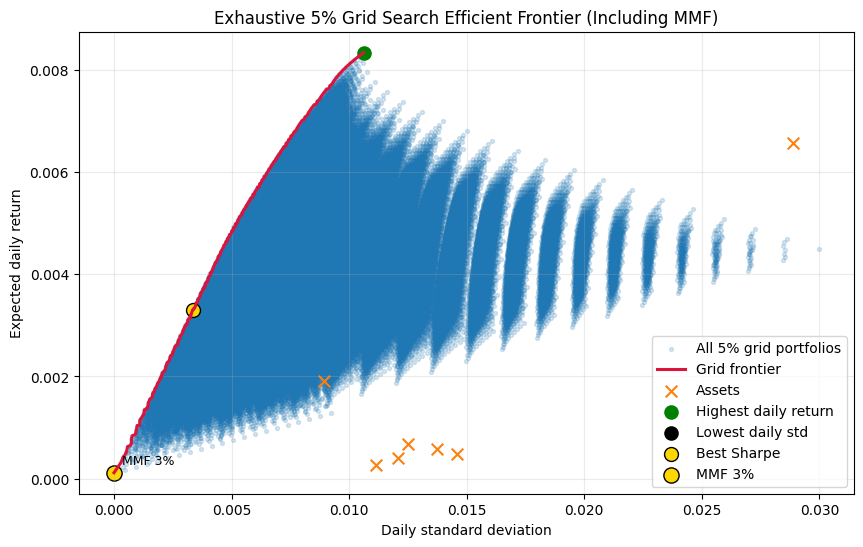

,portfolio_return_daily,portfolio_std_daily,w_NASA,w_3466.HK,w_DTCR,w_SPMO,w_VXUS,w_GRID,w_VTI,w_MMF_3pct
0,0.000117,0.000000,0.0,0.00,0.00,0.00,0.0,0.00,0.00,1.00
1,0.000320,0.000302,0.0,0.00,0.00,0.00,0.0,0.00,0.05,0.95
2,0.000427,0.000393,0.0,0.05,0.00,0.00,0.0,0.00,0.05,0.90
3,0.000459,0.000461,0.0,0.00,0.00,0.05,0.0,0.00,0.00,0.95
4,0.000528,0.000531,0.0,0.00,0.05,0.00,0.0,0.00,0.00,0.95
5,0.000630,0.000577,0.0,0.05,0.00,0.00,0.0,0.00,0.10,0.85
6,0.000635,0.000628,0.0,0.05,0.05,0.00,0.0,0.00,0.00,0.90
7,0.000662,0.000719,0.0,0.00,0.00,0.05,0.0,0.00,0.05,0.90
8,0.000699,0.000742,0.0,0.05,0.00,0.00,0.0,0.05,0.05,0.85
9,0.000768,0.000743,0.0,0.05,0.00,0.05,0.0,0.00,0.05,0.85


In [17]:
# Exhaustive 5% grid search across the tickers including the MMF
# This tests every valid portfolio where each weight is 0%, 5%, ..., 100% and weights sum to 100%.

from itertools import combinations

grid_assets = returns_with_mmf.columns.tolist()
grid_returns = returns_with_mmf[grid_assets].dropna()

if grid_returns.empty:
    raise ValueError('No overlapping return history available for the 7-asset grid search.')

grid_mu = (1 + grid_returns).prod() ** (1 / grid_returns.count()) - 1
grid_cov = grid_returns.cov()
step = 0.05
units = int(round(1 / step))
n_assets = len(grid_assets)
rf_daily = (1 + RISK_FREE_RATE_ANNUAL) ** (1 / TRADING_DAYS) - 1

def generate_weight_grid(n, total_units):
    """Yield all integer compositions of total_units into n buckets."""
    if n == 1:
        yield (total_units,)
        return
    for cuts in combinations(range(total_units + n - 1), n - 1):
        parts = []
        prev = -1
        for cut in cuts + (total_units + n - 1,):
            parts.append(cut - prev - 1)
            prev = cut
        if len(parts) == n:
            yield tuple(parts)

weight_rows = []
for units_tuple in generate_weight_grid(n_assets, units):
    weights = np.array(units_tuple, dtype=float) * step
    port_return = float(weights @ grid_mu.values)
    port_variance = float(weights @ grid_cov.values @ weights)
    port_std = float(np.sqrt(max(port_variance, 0.0)))
    weight_rows.append({
        'portfolio_return_daily': port_return,
        'portfolio_std_daily': port_std,
        'sharpe_daily': (port_return - rf_daily) / port_std if port_std > 0 else np.nan,
        **{f'w_{asset}': weight for asset, weight in zip(grid_assets, weights)},
    })

grid_df = pd.DataFrame(weight_rows).dropna(subset=['portfolio_std_daily'])
grid_df = grid_df.sort_values(['portfolio_std_daily', 'portfolio_return_daily']).reset_index(drop=True)

asset_mu_daily = (1 + returns_with_mmf).prod() ** (1 / returns_with_mmf.count()) - 1
asset_std_daily = returns_with_mmf.std()
mmf_idx = asset_mu_daily.index.get_loc(MMF_LABEL) if MMF_LABEL in asset_mu_daily.index else None

# Efficient frontier from the feasible grid: keep portfolios that are not dominated
grid_frontier = []
best_return_so_far = -np.inf
for _, row in grid_df.sort_values('portfolio_std_daily').iterrows():
    if row['portfolio_return_daily'] > best_return_so_far:
        grid_frontier.append(row)
        best_return_so_far = row['portfolio_return_daily']

grid_frontier_df = pd.DataFrame(grid_frontier).reset_index(drop=True)

best_daily_return = grid_df.loc[grid_df['portfolio_return_daily'].idxmax()]
min_std_portfolio = grid_df.loc[grid_df['portfolio_std_daily'].idxmin()]
best_sharpe_portfolio = grid_df.loc[grid_df['sharpe_daily'].idxmax()]

print(f'Tested {len(grid_df):,} portfolios using a {int(step * 100)}% weight grid.')
print('Best expected daily return portfolio:')
display(best_daily_return.to_frame().T)
print('Minimum daily standard deviation portfolio:')
display(min_std_portfolio.to_frame().T)
print('Best Sharpe-ratio portfolio:')
display(best_sharpe_portfolio.to_frame().T)

plt.figure(figsize=(10, 6))
plt.scatter(grid_df['portfolio_std_daily'], grid_df['portfolio_return_daily'], s=8, alpha=0.18, label='All 5% grid portfolios')
plt.plot(grid_frontier_df['portfolio_std_daily'], grid_frontier_df['portfolio_return_daily'], color='crimson', linewidth=2.2, label='Grid frontier')
plt.scatter(asset_std_daily.values, asset_mu_daily.values, marker='x', s=70, label='Assets')
plt.scatter([best_daily_return['portfolio_std_daily']], [best_daily_return['portfolio_return_daily']], color='green', s=90, label='Highest daily return')
plt.scatter([min_std_portfolio['portfolio_std_daily']], [min_std_portfolio['portfolio_return_daily']], color='black', s=90, label='Lowest daily std')
plt.scatter([best_sharpe_portfolio['portfolio_std_daily']], [best_sharpe_portfolio['portfolio_return_daily']], color='gold', edgecolor='black', s=100, label='Best Sharpe')
plt.xlabel('Daily standard deviation')
plt.ylabel('Expected daily return')
plt.title('Exhaustive 5% Grid Search Efficient Frontier (Including MMF)')
plt.grid(True, alpha=0.25)
if mmf_idx is not None:
    plt.scatter([asset_std_daily.iloc[mmf_idx]], [asset_mu_daily.iloc[mmf_idx]], color='gold', edgecolor='black', s=120, label='MMF 3%')
    plt.annotate('MMF 3%', (asset_std_daily.iloc[mmf_idx], asset_mu_daily.iloc[mmf_idx]), xytext=(6, 6), textcoords='offset points', fontsize=9)
plt.legend()
plt.show()

# Show the top 10 frontier portfolios
frontier_cols = ['portfolio_return_daily', 'portfolio_std_daily'] + [c for c in grid_frontier_df.columns if c.startswith('w_')]
display(grid_frontier_df[frontier_cols].head(10))

In [ ]:
# Interactive weight explorer for all tickers
# Adjust the sliders to change portfolio weights.
# The weights are normalized to sum to 100% automatically.
# The selected portfolio is also highlighted on the efficient frontier chart.

if 'efficient_frontier' not in globals():
    def efficient_frontier(mu, cov, n_points=60, long_only=True):
        mu = np.asarray(mu).reshape(-1)
        cov = np.asarray(cov)
        n = len(mu)

        w = cp.Variable(n)
        constraints_base = [cp.sum(w) == 1]
        if long_only:
            constraints_base.append(w >= 0)

        targets = np.linspace(float(mu.min()), float(mu.max()), n_points)
        pts = []
        for r_target in targets:
            constraints = constraints_base + [mu @ w >= r_target]
            prob = cp.Problem(cp.Minimize(cp.quad_form(w, cov)), constraints)
            try:
                prob.solve(solver=cp.OSQP, verbose=False)
            except Exception:
                prob.solve(solver=cp.SCS, verbose=False)
            if w.value is None:
                continue
            wv = np.asarray(w.value).reshape(-1)
            port_ret = float(mu @ wv)
            port_var = float(wv.T @ cov @ wv)
            port_vol = float(np.sqrt(max(port_var, 0.0)))
            pts.append({'return': port_ret, 'vol': port_vol, 'weights': wv})
        return pts

try:
    import ipywidgets as widgets
    from IPython.display import clear_output
except Exception as e:
    raise ImportError('Missing dependency: ipywidgets. Install with: pip install ipywidgets') from e
explorer_mu = (1 + explorer_returns).prod() ** (1 / explorer_returns.count()) - 1
explorer_assets = returns_with_mmf.columns.tolist()
explorer_returns = returns_with_mmf[explorer_assets].dropna()
if explorer_returns.empty:
    raise ValueError('No overlapping return history available for the interactive explorer.')
explorer_mu_annual = (1 + explorer_mu) ** TRADING_DAYS - 1
explorer_mu = explorer_returns.mean()
explorer_cov = explorer_returns.cov()
explorer_rf_daily = (1 + RISK_FREE_RATE_ANNUAL) ** (1 / TRADING_DAYS) - 1

        'return_daily': (1 + point['return']) ** (1 / TRADING_DAYS) - 1
explorer_mu_annual = explorer_mu * TRADING_DAYS
explorer_cov_annual = explorer_cov * TRADING_DAYS
explorer_frontier = efficient_frontier(explorer_mu_annual.values, explorer_cov_annual.values, n_points=60, long_only=True)
explorer_frontier_df = pd.DataFrame([
    {
        'return_daily': point['return'] / TRADING_DAYS,
        'std_daily': point['vol'] / np.sqrt(TRADING_DAYS),
        'weights': point['weights'],
    }
    for point in explorer_frontier
]).dropna()

slider_step = 5
slider_max = 100
sliders = {
    asset: widgets.IntSlider(
        value=int(round(100 / len(explorer_assets))),
        min=0,
        max=slider_max,
        step=slider_step,
        description=asset,
        continuous_update=False,
        readout=True,
        style={'description_width': '120px'},
        layout=widgets.Layout(width='420px')
    )
    for asset in explorer_assets
}

# Make the initial values sum to 100.
initial_total = sum(slider.value for slider in sliders.values())
if initial_total != 100:
    first_asset = explorer_assets[0]
    sliders[first_asset].value = sliders[first_asset].value + (100 - initial_total)

output = widgets.Output()


def _normalized_weights_from_sliders():
    raw = np.array([sliders[a].value for a in explorer_assets], dtype=float)
    if raw.sum() == 0:
        raw = np.ones_like(raw)
    normalized = raw / raw.sum()
    return normalized


def _render_portfolio(*args):
    weights = _normalized_weights_from_sliders()
    port_return = float(weights @ explorer_mu.values)
    port_variance = float(weights @ explorer_cov.values @ weights)
    port_std = float(np.sqrt(max(port_variance, 0.0)))
    sharpe = float((port_return - explorer_rf_daily) / port_std) if port_std > 0 else np.nan

    with output:
        clear_output(wait=True)
        display(pd.DataFrame({'weight': weights}, index=explorer_assets))
        display(pd.DataFrame({
            'daily_return': [port_return],
            'daily_std': [port_std],
            'daily_sharpe': [sharpe],
        }))

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.scatter(explorer_frontier_df['std_daily'], explorer_frontier_df['return_daily'], s=12, alpha=0.4, label='Efficient frontier')
        ax.plot(explorer_frontier_df['std_daily'], explorer_frontier_df['return_daily'], linewidth=1.5, alpha=0.8)
        ax.scatter([port_std], [port_return], color='red', s=110, edgecolor='black', label='Selected portfolio')
        ax.scatter(np.sqrt(np.diag(explorer_cov)), explorer_mu.values, marker='x', s=80, label='Assets')
        for x_val, y_val, name in zip(np.sqrt(np.diag(explorer_cov)), explorer_mu.values, explorer_assets):
            ax.annotate(name, (x_val, y_val), xytext=(4, 4), textcoords='offset points', fontsize=9)
        ax.set_xlabel('Daily standard deviation')
        ax.set_ylabel('Expected daily return')
        ax.set_title('Interactive Efficient Frontier')
        ax.grid(True, alpha=0.25)
        ax.legend()
        plt.show()

        fig2, ax2 = plt.subplots(figsize=(10, 5))
        ax2.bar(explorer_assets, weights)
        ax2.set_ylim(0, 1)
        ax2.set_ylabel('Portfolio weight')
        ax2.set_title('Normalized portfolio weights')
        ax2.grid(True, axis='y', alpha=0.25)
        plt.xticks(rotation=30, ha='right')
        plt.show()

        print(f'Expected daily return: {port_return:.6f}')
        print(f'Daily standard deviation: {port_std:.6f}')
        print(f'Daily Sharpe ratio: {sharpe:.6f}')

for slider in sliders.values():
    slider.observe(_render_portfolio, names='value')

controls = widgets.VBox(list(sliders.values()))
display(widgets.HBox([controls, output]))
_render_portfolio()